#**Generative Text Model Trained on a Corpus of Shakespeare (CharRNN)**




Let's download some Shakespeare

In [7]:
import keras
import numpy as np

filename = keras.utils.get_file(
    origin="https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt",
)
shakespeare = open(filename, "r").read()

Let's see what's in the corpus...

In [8]:
# The first 250 characters of text... including line breaks.
print(shakespeare[:250])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



Let's make some training observations...

In [20]:
import tensorflow as tf

# Each observation will be 100 characters long.
sequence_length = 100

# We take the original document and we split it into 100 character sequence chunks.
def split_input(input, sequence_length):

    # Loop over each 100-character segment of the text
    for i in range(0, len(input), sequence_length):

        # Return a list of those text chunks.
        yield input[i:i + sequence_length]

# Features (x's) are mutually exclusive blocks / chunks of 100 characters from the original text.
# We need to omit the final character because that will be the label in our last sequence.
features = list(split_input(shakespeare[:-1], sequence_length))

# Labels are also mutually exclusive blocks / chunks of 100 characters, offset from the input sequence by 1 character.
# We drop the first character here because we have nothing to its left with which to make a prediction.
labels = list(split_input(shakespeare[1:], sequence_length))

# We make a Tensorflow Dataset object from these lists of 100 character strings.
dataset = tf.data.Dataset.from_tensor_slices((features, labels))

Here are the first two observations

In [10]:
for i, (features, labels) in enumerate(dataset.as_numpy_iterator()):
  print(features[:20])
  print(labels[:20])
  if i==1:
    break

b'First Citizen:\nBefor'
b'irst Citizen:\nBefore'
b' are all resolved ra'
b'are all resolved rat'


We now use a TextVectorization layer to split out individual characters in each sequence and convert them into numeric values (integer indices). We apply that layer to our Tensorflow Dataset as a lambda operation. We will work with a character-level model because there are way fewer values to predict in our softmax this way :). We have 26 letters * 2 (upper vs. lower case), plus punctuation, spaces, back slashes, and such. We have just 67 unique characters in the entire document.

In [21]:
from keras import layers

# Define the layer
tokenizer = layers.TextVectorization(
    standardize=None,
    split="character",
    output_sequence_length=sequence_length,
)

# Apply it to the text we pull from our dataset (dropping the labels since we don't need those when adapting the TextVectorization layer)
tokenizer.adapt(dataset.map(lambda text, labels: text))

vocabulary_size = tokenizer.vocabulary_size()

print(f'We have {vocabulary_size} unique characters in our document.')

We have 67 unique characters in our document.


Now we can use the tokenizer to tokenize the text coming out of the Dataset.

In [22]:
dataset = dataset.map(
    lambda features, labels: (tokenizer(features), tokenizer(labels)),
    num_parallel_calls=8,
)

# We have to shuffle the data up front here because we are using a Tensorflow dataset object.
# Unlike when all our data is sitting in memory, model.fit(shuffle=True) will not shuffle the order of observations
# when we have a Dataset object as input. This is because the fit() function only has access to one batch at a time.
# It actually just shuffles the order of batches that it pulls from the Dataset.
# In contrast, when data is all in memory, the model.fit() call shuffles observations ahead of time, before creating batches.
training_data = dataset.batch(64).cache().shuffle(10_000)

print(f'We have created a dataset object that has {dataset.cardinality()} observations.')

We have created a dataset object that has 11154 observations.


### Understanding Multi-Position Prediction

During training, the model predicts the next character at **every position simultaneously** in a single forward pass. This is purely an efficiency trick — each position only "sees" characters before it (because the RNN processes left to right).

**Concrete example** — suppose our sequence is `S h a k e s`:

```
Input:    S  h  a  k  e       (characters 0-4)
Target:   h  a  k  e  s       (characters 1-5)

Position 0: RNN has seen [S]         → predicts 'h'
Position 1: RNN has seen [S,h]       → predicts 'a'
Position 2: RNN has seen [S,h,a]     → predicts 'k'
Position 3: RNN has seen [S,h,a,k]   → predicts 'e'
Position 4: RNN has seen [S,h,a,k,e] → predicts 's'
```

All 5 predictions happen in **one forward pass**. The loss is the average cross-entropy across all positions. This is equivalent to running the model 5 separate times with progressively longer inputs — but ~5x faster.

The model output shape is `(batch_size, sequence_length, vocab_size)` — a probability distribution over all 67 characters at each position.

#*The Architecture for CharRNN Model...*

In [23]:
# Input will be 100 integer values per sequence (x implicit batch size)
inputs = layers.Input(shape=(sequence_length,), dtype="int", name="integer_seq_input")

# We project each integer index into a 256 dimensional embedding space.
x = layers.Embedding(input_dim=vocabulary_size, output_dim=256)(inputs)

# We pass the sequence of embeddings into an RNN (a GRU in this case).
# We have 1,024 GRU units here (so we will obtain a hidden state vector of 1,024 values at each step)
# Again, this can be thought of as a form of embedding for the sequence up to that point.
x = layers.GRU(1024, return_sequences=True)(x)

# We then have a bit of dropout
x = layers.Dropout(0.1)(x)

# And a softmax prediction among the 67 unique characters.
# Note, again, this is deceptive; the shape of the output will be a sequence of 100 softmax values, each with 67 classes.
outputs = layers.Dense(vocabulary_size, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# For all 100 characters that enter the model in a given observation...
# we make parallel predictions for the character that should come next, using a softmax.
# Notice the shape of our output layer is 100, 67-dimensional predictions per observation.
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ integer_seq_input (InputLayer)  │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 256)       │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100, 1024)      │     3,938,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 1024)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100, 67)        │        68,675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,024,131 (15.35 MB)

 Trainable params: 4,024,131 (15.35 MB)

 Non-trainable params: 0 (0.00 B)

And how does it look visually?

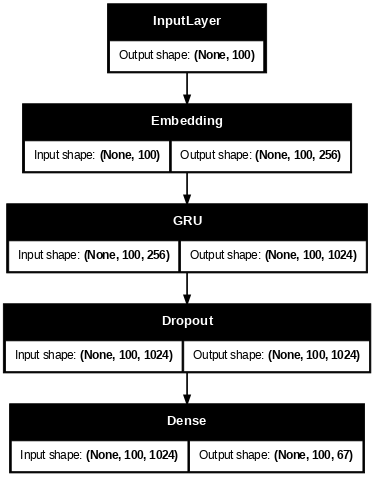

In [24]:
keras.utils.plot_model(model, show_shapes=True, dpi=60)

Train the model...

In [25]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)

model.fit(training_data, epochs=20)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 2.5785 - sparse_categorical_accuracy: 0.3101
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9340 - sparse_categorical_accuracy: 0.4304
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7009 - sparse_categorical_accuracy: 0.4937
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5632 - sparse_categorical_accuracy: 0.5304
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.4766 - sparse_categorical_accuracy: 0.5526
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.4153 - sparse_categorical_accuracy: 0.5686
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.3675 - sparse_categorical_accuracy: 0.5802
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.3257 - sparse_categorical_accuracy: 0.5911
Epoch 9/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.2884 - sparse_categorical_accuracy: 0.6007
Epoch 10/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11

### Why Change Architecture for Inference?

We don't really NEED to change the architecture. We could have set return_state=True in the training architecture, and it would have worked fine for inference. We are doing this more for clarity's sake. Our trained model had return_sequences=True, but we are setting it false now. And, we didn't have return_state, which we are enabling now.

During generations, we will...

1. Feed in a single character (the most recent output character) + the hidden state from the last prediction step.

2. Get back the next prediction and updated hidden state.

3. Feed the prediction back as the next input to repeat the process.

We set `return_sequences=False`, though it doesn't matter much since sequences are of length 1, and we add explicit state management, passing the hidden state resulting from one prediction as input to the next.

Here, we transfer the **learned weights** from the training model into the generation model's architecture, copying them in.

Now let's see what this model produces as output. To make this work, we need to implement the feedback mechanisms for auto-regressive text production.

In [26]:
# We need two input layers for our generative model.
# One input layer will receive a single character token (the last prediction)
# The second input layer will receive the hidden / embedded representation of the sequence as of the last prediction that was made.
# We are going to udpate and carry the hidden state forward into each subsequent prediction.
# This is kind of like what an RNN does internally, but we are doing it manually outside of the model.

# Note that our generation model will take only 1 token as input.
inputs = keras.Input(shape=(1,), dtype="int", name="integer_seq_input")

# It also takes a 1,024 dim embedded representation of the sequence (up to the point of the current prediction) as additional input.
input_state = keras.Input(shape=(1024,), name="state")

# The last token is passed through our embedding layer
x = layers.Embedding(vocabulary_size, 256)(inputs)

# The 1,024 embedded representation gets passed into the GRU, along with the embedding of the last token we produced.
# Note that this GRU does not return sequences, but that's not so important given we only have sequences of length 1 going into it at each generation.
# We also have return_state = True now so we can manually loop the hidden state from one generation into the next.
x, output_state = layers.GRU(1024, return_state=True)(x, initial_state=input_state)

# We predict the next token.
outputs = layers.Dense(vocabulary_size, activation="softmax")(x)

# And our model will return i) the next token prediction, as well as ii) the current 1,024 dimensional representation of the sequence at the point of the new prediction.
generation_model = keras.Model(
    inputs=(inputs, input_state),
    outputs=(outputs, output_state),
)

# Note that our architecture is identical in terms of the weight count;
# All that changed is that we no longer return sequences, and we will only ever
# pass sequences of one token at a time, as input, accumulating the hidden
# state manually across generation steps and looping it back into the GRU.
# This step initializes the weights
generation_model.set_weights(model.get_weights())

Prepare data and dictionaries to work with our generative model...

In [31]:
tokens = tokenizer.get_vocabulary()
token_ids = range(vocabulary_size)

# We are making dictionaries that we will use to go back and forth from integer indices to readable words...
char_to_id = dict(zip(tokens, token_ids))
id_to_char = dict(zip(token_ids, tokens))

# Our starting prompt for the language model...
# We will pass these tokens through our generative model to 'burn in' a starting value for the hidden state, so the model can then produce something meaningful as output.
prompt = """KING RICHARD III:\n"""

Now we 'burn in' the generative model over our starting text (prompt), so we can get to a meaningful hidden state value for when we start generating our first next character.

In [36]:
input_ids = [char_to_id[c] for c in prompt]

# We start with a state of 0, and we will update the state vector by passing over the first several characters.
state = keras.ops.zeros(shape=(1, 1024))
print(f'Starting state is f{state}\n')

for token_id in input_ids:
    inputs = keras.ops.expand_dims([token_id], axis=0)
    predictions, state = generation_model((inputs, state))

    # At each token, we can see what it is predicting to begin with, and we see it is making mistakes during the burn-in period.
    # But this is the generative model essentially first calibrating to the prompt.
    print(id_to_char[token_id],"-->",id_to_char[np.argmax(predictions)],"\n", end="", flush=True)

print(f'Ending state is f{state}')


Starting state is f[[0. 0. 0. ... 0. 0. 0.]]

K --> I 
I --> N 
N --> G 
G -->   
  --> R 
R --> I 
I --> C 
C --> H 
H --> A 
A --> R 
R --> D 
D -->   
  --> I 
I --> I 
I --> : 
I --> : 
: --> 
 

 --> A 
Ending state is f[[-0.40206203  0.05838345  0.3625912  ... -0.5100025   0.49866474
   0.99388504]]


Now we can use the 'calibrated' model to produce subsequent text.

In [37]:
import numpy as np

# We will append our autoregressive predictions into a list, one at a time.
generated_ids = []

# Let's produce 300 tokens of output.
max_length = 300

prompt = """KING RICHARD III:\n"""

print(prompt)

for i in range(max_length):
    next_char = int(np.array(keras.ops.argmax(predictions, axis=-1)[0]))
    generated_ids.append(next_char)
    inputs = keras.ops.expand_dims([next_char], axis=0)

    # Reshape the state vector so its the right dimensionality for our input layer.
    # state = keras.ops.expand_dims(state, axis=0) # This line was the problem and has been commented out
    predictions, state = generation_model((inputs, state))
    if state.ndim == 3:
        state = keras.ops.squeeze(state, axis=1)
    print(id_to_char[next_char], end="", flush=True)

KING RICHARD III:

And say we will commend thee forth to purchase women
To see the son, whom we have spoke to hear
As I do send the heavens and royal precious crown
To think our countrymen and with such a pleasure;
And therefore for a great common persuade him.

KING R